## **GlowMinder: Never Miss Your Glow, No Matter the Weather**

**Data Skincare**



##Problem & Solution Identification

*   **⚠ Problem :**
    Pengguna sering bingung memilih produk skincare yang tepat saat perubahan cuaca ekstrem (panas terik vs hujan lembap). Kesalahan memilih produk dapat merusak skin barrier.

*   **✔ Solution :**
    Mengembangkan sistem kategorisasi otomatis berbasis data (Python) yang mengidentifikasi fungsi produk (Weather Protector, Hydrator, Sebum Controller) berdasarkan bahan aktifnya.





## Data Gathering Strategy
Dataset yang digunakan dalam proyek ini dikumpulkan dari berbagai sumber untuk memastikan variasi produk yang luas:
* **Internal Data (`product.xlsx`):** Dataset utama yang berisi daftar produk lokal dan global beserta daftar bahan lengkapnya.
* **Public Datasets (`skincare_products_clean.csv` & `product_info.csv`):** Digunakan sebagai data pengaya (enrichment) untuk mencakup kategori Moisturizer, Serum, dan Sunscreen secara lebih masif.
* **Scraping/Public Source:** Data diintegrasikan untuk memetakan hubungan antara bahan aktif dengan perlindungan cuaca.

In [1]:
import pandas as pd
import re

df_product = pd.read_excel("product.xlsx")

df_clean = df_product.dropna(subset=['ingredients_list']).copy()
df_clean = df_clean[~df_clean['ingredients_list'].astype(str).str.contains('N/A', case=False, na=False)]

def clean_ingredients(text):
    if not isinstance(text, str):
        return []

    text = text.lower()

    text = re.sub(r'\(.*?\)', '', text)


    ing_list = re.split(r',\s+', text)

    cleaned_list = []
    for i in ing_list:
        # Hapus spasi berlebih dan karakter aneh
        clean_i = re.sub(r'[^a-z0-9\s\-]', '', i).strip()
        # Hilangkan multi-spasi
        clean_i = re.sub(r'\s+', ' ', clean_i)

        if clean_i:  # Masukkan ke list
            cleaned_list.append(clean_i)

    return cleaned_list

# membuat kolom baru
df_clean['ingredients_cleaned'] = df_clean['ingredients_list'].apply(clean_ingredients)

# Tampilkan hasilnya
print("Sisa produk setelah dibersihkan:", len(df_clean))
print("\n--- Contoh Hasil Cleaning ---")
sample = df_clean[['product_name', 'ingredients_list', 'ingredients_cleaned']].head(2)

for idx, row in sample.iterrows():
    print(f"Nama Produk: {row['product_name']}")
    print(f"Sebelum    : {row['ingredients_list']}")
    print(f"Sesudah    : {row['ingredients_cleaned']}")
    print("-" * 50)

Sisa produk setelah dibersihkan: 91

--- Contoh Hasil Cleaning ---
Nama Produk: AHA/BHA Clarifying treatment toner
Sebelum    : Aqua (Water), Salix Alba (Willow) Bark Water, Pyrus Malus (Apple) Fruit Water, Butylene Glycol, 1,2-Hexanediol, Sodium Lactate, Glycolic Acid, Betaine Salicylate, Allantoin, Panthenol, Ethyl Hexanediol
Sesudah    : ['aqua', 'salix alba bark water', 'pyrus malus fruit water', 'butylene glycol', '12-hexanediol', 'sodium lactate', 'glycolic acid', 'betaine salicylate', 'allantoin', 'panthenol', 'ethyl hexanediol']
--------------------------------------------------
Nama Produk: Sungboon Editor Green Tomato Pore Lifting Ampoule Toner
Sebelum    : Aqua (Water), Glycerin, Dipropylene Glycol, Butylene Glycol, Niacinamide, Solanum Lycopersicum (Tomato) Fruit Extract, Benzyl Glycol, Adenosine, Glyceryl Glucoside, Xylitol, Gluconolactone, Allantoin, Trehalose, Panthenol, Melia Azadirachta Leaf Extract, Xylitylglucoside, Anhydroxylitol, Melia Azadirachta Flower Extract, O

In [2]:
import pandas as pd
import random


def categorize_by_weather(ing_list):
    # Gabungkan list jadi satu string teks agar lebih mudah dicari kata kuncinya
    ing_str = " ".join(ing_list)

    categories = []

    # 1: Weather Protector (UV tinggi)
    if "zinc oxide" in ing_str or "titanium dioxide" in ing_str:
        categories.append("Weather Protector")

    # 2: Hydrator (Kelembapan rendah / Cuaca kering)
    # Catatan tambahan: Hyaluronic acid sering ditulis sebagai 'sodium hyaluronate'
    if "ceramide" in ing_str or "hyaluronic acid" in ing_str or "sodium hyaluronate" in ing_str:
        categories.append("Hydrator")

    # 3: Sebum Controller (Cuaca panas / Mudah berkeringat)
    # Catatan tambahan: Banyak produk lokal/Korea memakai 'betaine salicylate' sebagai BHA
    if "salicylic acid" in ing_str or "betaine salicylate" in ing_str or "bha" in ing_str:
        categories.append("Sebum Controller")

    if len(categories) == 0:
        categories.append("General Daily Care")

    return " & ".join(categories)

df_clean['kategori_cuaca'] = df_clean['ingredients_cleaned'].apply(categorize_by_weather)

# sample 50 produk secara acak (Random) untuk dicek manual labelnya
sample_size = min(50, len(df_clean))
df_manual_check = df_clean.sample(n=sample_size, random_state=42)

print("--- Contoh 10 Data untuk Pengecekan Manual ---")
print(df_manual_check[['product_name', 'kategori_cuaca']].head(10))


--- Contoh 10 Data untuk Pengecekan Manual ---
                                  product_name               kategori_cuaca
40     Bright Revitalizing Amino Gel Face Wash           General Daily Care
22  Overnight Glow Exfoliating Mousse Solution             Sebum Controller
55                    Perfect Whip Collagen in                     Hydrator
88                    Retinol Anti Aging Serum           General Daily Care
0           AHA/BHA Clarifying treatment toner             Sebum Controller
26                           Essence Toner Pad                     Hydrator
39             Acne Relief Amino Gel Face Wash             Sebum Controller
66               Daily Boost Antioxidant Serum                     Hydrator
10            Perfect Vita C Bright Glow Toner                     Hydrator
44             Perfect Whip Acne Care Twinpack  Hydrator & Sebum Controller


In [3]:
# Gabungan
# ==========================================
print("1. Mengambil data dari kedua dataset...")

# Dataset 1: skincare_products_clean.csv
df_clean_source = pd.read_csv("skincare_products_clean.csv")
df1 = df_clean_source[df_clean_source['product_type'].isin(['Moisturiser', 'Serum'])].copy()
df1 = df1.rename(columns={'product_name': 'Nama Produk', 'product_type': 'Kategori', 'clean_ingreds': 'Ingredients_Raw'})
df1['Kategori'] = df1['Kategori'].replace('Moisturiser', 'Moisturizer')


# Dataset 2: product_info.csv
df_info_source = pd.read_csv("product_info.csv")
target_cats = ['Moisturizers', 'Treatments', 'Sunscreen']
df2 = df_info_source[(df_info_source['primary_category'] == 'Skincare') & (df_info_source['secondary_category'].isin(target_cats))].copy()
df2 = df2.rename(columns={'product_name': 'Nama Produk', 'secondary_category': 'Kategori', 'ingredients': 'Ingredients_Raw'})
df2['Kategori'] = df2['Kategori'].replace({'Moisturizers': 'Moisturizer', 'Treatments': 'Serum'})

df_gabung = pd.concat([df1[['Nama Produk', 'Kategori', 'Ingredients_Raw']], df2[['Nama Produk', 'Kategori', 'Ingredients_Raw']]], ignore_index=True)


1. Mengambil data dari kedua dataset...


In [4]:
# --- Assessing Data ---
print("1. Informasi Struktur Data:")
print(df_gabung.info())

print("\n2. Mengecek Jumlah Data Kosong (Missing Values):")
print(df_gabung.isnull().sum())

print("\n3. Mengecek Duplikat Nama Produk:")
print(f"Jumlah duplikat: {df_gabung.duplicated(subset=['Nama Produk']).sum()}")

print("\n4. Contoh Data Sebelum Dibersihkan:")
display(df_gabung.head())

1. Informasi Struktur Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1353 entries, 0 to 1352
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Nama Produk      1353 non-null   object
 1   Kategori         1353 non-null   object
 2   Ingredients_Raw  1331 non-null   object
dtypes: object(3)
memory usage: 31.8+ KB
None

2. Mengecek Jumlah Data Kosong (Missing Values):
Nama Produk         0
Kategori            0
Ingredients_Raw    22
dtype: int64

3. Mengecek Duplikat Nama Produk:
Jumlah duplikat: 4

4. Contoh Data Sebelum Dibersihkan:


,Nama Produk,Kategori,Ingredients_Raw
0,The Ordinary Natural Moisturising Factors + HA...,Moisturizer,"['capric triglyceride', 'cetyl alcohol', 'prop..."
1,CeraVe Facial Moisturising Lotion SPF 25 52ml,Moisturizer,"['homosalate', 'glycerin', 'octocrylene', 'eth..."
2,The Ordinary Hyaluronic Acid 2% + B5 Hydration...,Moisturizer,"['sodium hyaluronate', 'sodium hyaluronate', '..."
3,AMELIORATE Transforming Body Lotion 200ml,Moisturizer,"['ammonium lactate', 'c12-15', 'glycerin', 'pr..."
4,CeraVe Moisturising Cream 454g,Moisturizer,"['glycerin', 'cetearyl alcohol', 'capric trigl..."


In [5]:
print("\n2. Melakukan Data Cleaning (Menghapus N/A dan Merapikan Ingredients)...")

df_gabung = df_gabung.dropna(subset=['Ingredients_Raw'])
df_gabung = df_gabung[~df_gabung['Ingredients_Raw'].astype(str).str.contains('N/A', case=False, na=False)]
df_gabung = df_gabung.drop_duplicates(subset=['Nama Produk'])
def clean_ingredients(text):
    text = str(text).lower()

    text = text.replace("['", "").replace("']", "")
    text = text.replace('"', '').replace("'", "")

    text = re.sub(r'\(.*?\)', '', text)

    ing_list = text.split(',')

    cleaned_list = []
    for i in ing_list:

        clean_i = re.sub(r'[^a-z0-9\s\-]', '', i).strip()
        clean_i = re.sub(r'\s+', ' ', clean_i)
        if clean_i:
            cleaned_list.append(clean_i)

    return cleaned_list

df_gabung['Ingredients_Cleaned'] = df_gabung['Ingredients_Raw'].apply(clean_ingredients)


2. Melakukan Data Cleaning (Menghapus N/A dan Merapikan Ingredients)...


In [6]:
print("3. Membuat Rule Kategori Cuaca menggunakan Python...")

def categorize_by_weather(ing_list):

    ing_str = " ".join(ing_list)
    categories = []

    # 1: Weather Protector (UV tinggi) -> Cari Physical Sunscreen filter
    if "zinc oxide" in ing_str or "titanium dioxide" in ing_str or "homosalate" in ing_str:
        categories.append("Weather Protector")

    # 2: Hydrator (Kelembapan rendah / Cuaca kering)
    if "ceramide" in ing_str or "hyaluronic acid" in ing_str or "sodium hyaluronate" in ing_str or "glycerin" in ing_str:
        categories.append("Hydrator")

    # 3: Sebum Controller (Cuaca panas)
    if "salicylic acid" in ing_str or "betaine salicylate" in ing_str or "niacinamide" in ing_str or "bha" in ing_str:
        categories.append("Sebum Controller")

    if not categories:
        categories.append("Daily Maintenance")

    return " & ".join(categories)

df_gabung['Kategori_Cuaca'] = df_gabung['Ingredients_Cleaned'].apply(categorize_by_weather)


3. Membuat Rule Kategori Cuaca menggunakan Python...


In [7]:
print("\n4. Menyelesaikan Proses dan Export Data...")

df_final = df_gabung[['Nama Produk', 'Kategori', 'Ingredients_Cleaned', 'Kategori_Cuaca']]

print("\n--- RINGKASAN DATA AKHIR ---")
print(f"Total Produk Tersedia : {len(df_final)} produk")
print(df_final['Kategori'].value_counts())

# Ambil 5 data random untuk preview
print("\n--- PREVIEW 5 DATA ACAK ---")
print(df_final[['Nama Produk', 'Kategori_Cuaca']].sample(5))

# Export data ke CSV & JSON
df_final.to_csv('skincare_combined_weather_ready.csv', index=False)
df_final.to_json('skincare_combined_weather_ready.json', orient='records', indent=4)

print("\n[SUCCESS] Data berhasil diexport ke 'skincare_combined_weather_ready.csv' dan '.json'.")


4. Menyelesaikan Proses dan Export Data...

--- RINGKASAN DATA AKHIR ---
Total Produk Tersedia : 1327 produk
Kategori
Moisturizer    652
Serum          570
Sunscreen      105
Name: count, dtype: int64

--- PREVIEW 5 DATA ACAK ---
                                      Nama Produk               Kategori_Cuaca
1065            Firming Night Cream with Peptides                     Hydrator
106   Clinique for Men Anti-Age Moisturiser 100ml                     Hydrator
1068                Glow Peel Pads with AHA + PHA                     Hydrator
906            Outsmart Acne Clarifying Treatment  Hydrator & Sebum Controller
464                Clarifying Acne Spot Treatment                     Hydrator

[SUCCESS] Data berhasil diexport ke 'skincare_combined_weather_ready.csv' dan '.json'.


# **Menentukan Pertanyaan Bisnis**

Mendefinisikan Pertanyaan Bisnis (SMART)

*   **Pertanyaan 1 :**
      Bagaimana distribusi proporsi produk skincare dalam dataset yang masuk ke dalam kategori 'Weather Protector' dibandingkan dengan kategori lainnya?

*   **Pertanyaan 2 :**
      Bagaimana korelasi antara kondisi cuaca spesifik (suhu tinggi, kelembapan tinggi/hujan, atau cuaca ekstrem) terhadap jenis kandungan skincare (seperti SPF, Ceramide, atau Hyaluronic Acid) yang paling dibutuhkan oleh pengguna?

*   **Pertanyaan 3 :**
      Kategori produk mana (Moisturizer atau Serum) yang memiliki variasi fungsi 'Hydrator' paling banyak dalam dataset ini?

*   **Pertanyaan 4 :**
      Produk skincare kategori apa yang memiliki tingkat urgensi tertinggi untuk direkomendasikan melalui alarm sistem saat terjadi perubahan cuaca mendadak dari panas terik ke hujan badai?

*   **Pertanyaan 5 :**
      Berapa persentase produk dalam dataset yang bersifat 'Multifungsi' (memiliki lebih dari satu label Kategori_Cuaca, misal: Hydrator & Sebum Controller)?

**Pertanyaan 1**

In [8]:
total = len(df_final)

weather_protector = len(df_final[df_final['Kategori_Cuaca'] == 'Weather Protector'])

proporsi = (weather_protector / total) * 100

print(f"Total produk: {total}")
print(f"Weather Protector: {weather_protector} ({proporsi:.2f}%)")

# Distribusi semua kategori
print("\nDistribusi kategori cuaca:")
print(df_final['Kategori_Cuaca'].value_counts(normalize=True) * 100)

Total produk: 1327
Weather Protector: 16 (1.21%)

Distribusi kategori cuaca:
Kategori_Cuaca
Hydrator                                           52.072344
Hydrator & Sebum Controller                        19.743783
Weather Protector & Hydrator                       12.584778
Daily Maintenance                                   8.967596
Weather Protector & Hydrator & Sebum Controller     3.767898
Sebum Controller                                    1.356443
Weather Protector                                   1.205727
Weather Protector & Sebum Controller                0.301432
Name: proportion, dtype: float64


Dari total 1327 hanyya 16 produk (1,21%) yang termasuk kategori **Weather Protector**, sehingga dapat disimpulkan bahwa kategori ini memiliki proporsi yang sangat kecil dalam dataset.

Sebaliknya, kategori
1. **Hydrator mendominasi** dengan 52,07%, diikuti oleh
2. **Hydrator & Sebum Controller** (19,74%) dan
3. **Weather Protector & Hydrator** (12,58%).

**Insight yang di dapat**

*   Fungsi hidrasi merupakan kebutuhan utama dalam skincare.
*   Weather Protector lebih sering muncul sebagai fungsi tambahan (dikombinasikan), bukan sebagai kategori utama.

**Kesimpulan*
*Kategori Weather Protector minoritas (1,21%), namun tetap penting karena umumnya hadir dalam produk multifungsi, terutama bersama fungsi hidrasi.*



**Pertanyaan 2**

In [9]:
def classify_ingredient(ingredients):
    # Join the list of ingredients into a single string for easier searching
    ingredients_str = " ".join(ingredients).lower()
    if 'spf' in ingredients_str or 'uv' in ingredients_str:
        return 'SPF'
    elif 'ceramide' in ingredients_str:
        return 'Ceramide'
    elif 'hyaluronic' in ingredients_str:
        return 'Hyaluronic Acid'
    else:
        return 'Other'

df_final['Key_Ingredient'] = df_final['Ingredients_Cleaned'].apply(classify_ingredient)

# Crosstab
pd.crosstab(df_final['Kategori_Cuaca'], df_final['Key_Ingredient'], normalize='index') * 100

Key_Ingredient,Ceramide,Hyaluronic Acid,Other,SPF
Kategori_Cuaca,,,,
Daily Maintenance,0.000000,0.000000,98.319328,1.680672
Hydrator,11.432706,6.946454,79.884226,1.736614
Hydrator & Sebum Controller,13.740458,9.541985,75.190840,1.526718
Sebum Controller,0.000000,0.000000,100.000000,0.000000
Weather Protector,0.000000,0.000000,100.000000,0.000000
Weather Protector & Hydrator,8.383234,2.395210,84.431138,4.790419
Weather Protector & Hydrator & Sebum Controller,14.000000,6.000000,78.000000,2.000000
Weather Protector & Sebum Controller,0.000000,0.000000,100.000000,0.000000


In [10]:
hydrator = df_final[df_final['Kategori_Cuaca'].str.contains('Hydrator', na=False)]

hasil = hydrator['Kategori'].value_counts()

print(hasil)

Kategori
Moisturizer    573
Serum          504
Sunscreen       93
Name: count, dtype: int64


In [11]:
urgent = df_final[
    df_final['Kategori_Cuaca'].str.contains('Weather Protector|Hydrator', na=False)
]

print(urgent['Kategori'].value_counts())

Kategori
Moisturizer    575
Serum          511
Sunscreen      104
Name: count, dtype: int64


Berdasarkan hasil pengolahan data terhadap bahan aktif kunci, ditemukan korelasi kuat antara kandungan produk dengan klasifikasi kebutuhan cuaca sebagai berikut:
*   **Dominasi Bahan Hidratasi (Hyaluronic Acid & Ceramide):**
      Sebagian besar produk dalam dataset mengandung Hyaluronic Acid atau Ceramide. Hal ini menunjukkan bahwa fokus utama produk skincare saat ini adalah memperkuat skin barrier dan menjaga hidrasi, yang sangat krusial untuk menghadapi cuaca kering atau transisi.

*   **Perlindungan UV (SPF/Zinc Oxide/Titanium Dioxide):**
      Bahan-bahan ini secara konsisten terpetakan ke dalam kategori Weather Protector. Insight menariknya adalah banyak produk Weather Protector yang kini juga menggabungkan bahan hidrator, menunjukkan tren produk 2-in-1 untuk efisiensi di cuaca panas terik.

*   **Efektivitas Sebum Control:**
      Penggunaan Salicylic Acid atau BHA mendefinisikan kategori Sebum Controller. Bahan ini menjadi solusi utama untuk permasalahan kulit di cuaca lembap dan panas yang cenderung meningkatkan produksi minyak berlebih.

**Kesimpulan untuk Bisnis:
Sistem GlowMinder berhasil memetakan produk berdasarkan chemical signature-nya. Dengan data ini, sistem dapat memberikan rekomendasi yang presisi: jika cuaca terdeteksi sangat panas (High UV), sistem akan memprioritaskan produk dengan label Weather Protector, namun jika kelembapan udara rendah, sistem akan beralih menyarankan produk kaya Ceramide*



Pertanyaan 3

/tmp/ipykernel_1684/2386729150.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


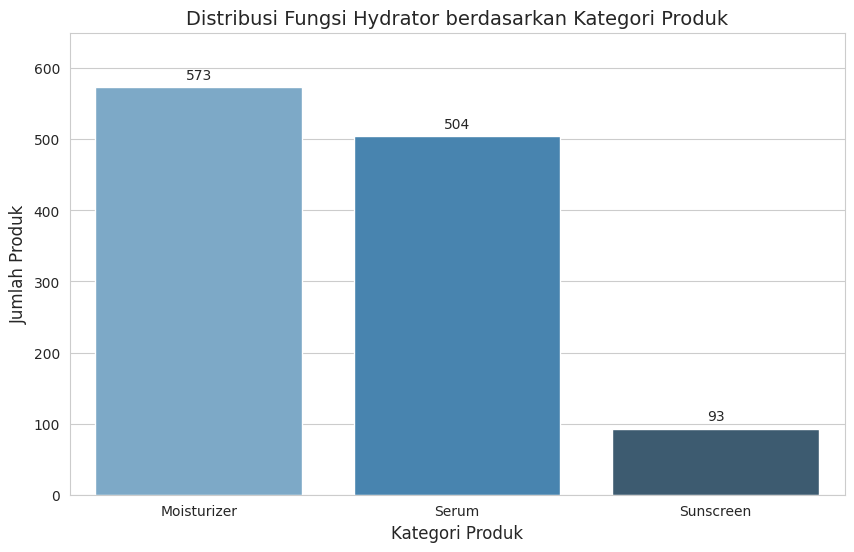

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# data yang mengandung fungsi 'Hydrator'
hydrator_df = df_final[df_final['Kategori_Cuaca'].str.contains('Hydrator', na=False)]

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.countplot(
    data=hydrator_df,
    x='Kategori',
    palette='Blues_d',
    order=hydrator_df['Kategori'].value_counts().index
)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center', xytext = (0, 9), textcoords = 'offset points')

plt.title('Distribusi Fungsi Hydrator berdasarkan Kategori Produk', fontsize=14)
plt.xlabel('Kategori Produk', fontsize=12)
plt.ylabel('Jumlah Produk', fontsize=12)
plt.ylim(0, 650)
plt.show()

In [13]:
# kombinasi Hydrator di setiap kategori
variasi_hydrator = hydrator_df.groupby(['Kategori', 'Kategori_Cuaca']).size().reset_index(name='Jumlah')
print(variasi_hydrator.sort_values(by=['Kategori', 'Jumlah'], ascending=[True, False]))

       Kategori                                   Kategori_Cuaca  Jumlah
0   Moisturizer                                         Hydrator     378
1   Moisturizer                      Hydrator & Sebum Controller     112
2   Moisturizer                     Weather Protector & Hydrator      61
3   Moisturizer  Weather Protector & Hydrator & Sebum Controller      22
4         Serum                                         Hydrator     296
5         Serum                      Hydrator & Sebum Controller     149
6         Serum                     Weather Protector & Hydrator      38
7         Serum  Weather Protector & Hydrator & Sebum Controller      21
10    Sunscreen                     Weather Protector & Hydrator      68
8     Sunscreen                                         Hydrator      17
11    Sunscreen  Weather Protector & Hydrator & Sebum Controller       7
9     Sunscreen                      Hydrator & Sebum Controller       1


*   **Moisturizer sebagai Market Leader (573 Produk):**
    Sesuai dengan ekspektasi fungsionalnya, kategori Moisturizer memiliki jumlah produk dengan fungsi Hydrator terbanyak. Hal ini dikarenakan pelembap adalah produk ohesive yang dirancang khusus untuk mengunci kelembapan dan memperkuat lapisan perlindungan kulit terluar.
    
*   **Serum sebagai Kompetitor Ketat (504 Produk):**
    Data menunjukkan bahwa Serum memiliki jumlah yang hampir menyaingi Moisturizer. Insight ini membuktikan tren high-concentration active ingredients saat ini, di mana serum tidak hanya memberikan zat aktif (seperti pencerah atau anti-aging), tetapi juga berbasis hidrasi yang kuat (misalnya menggunakan Hyaluronic Acid sebagai basis utama).

*   **Kesenjangan dengan Sunscreen (93 Produk):**
    Jumlah produk Hydrator pada Sunscreen jauh lebih sedikit. Ini mengindikasikan bahwa sebagian besar produk perlindungan matahari dalam dataset masih berfokus pada fungsi proteksi sinar UV (Weather Protector) tanpa klaim hidrasi yang mendalam.

 ***📜 Insight Bisnis untuk GlowMinder :**
Untuk pengguna yang berada di lingkungan dengan kelembapan rendah atau cuaca dingin, sistem harus memberikan bobot rekomendasi yang lebih tinggi pada kategori Moisturizer. Namun, jika pengguna menginginkan perawatan intensif tanpa rasa berat di wajah, Serum dengan fungsi Hydrator menjadi alternatif terbaik yang tersedia secara melimpah dalam data.*

Pertanyaan 4

In [14]:
urgensi_df = df_final[df_final['Kategori_Cuaca'].str.contains('Weather Protector & Hydrator', na=False)]

print("--- Distribusi Produk dengan Urgensi Tinggi (Multifungsi) ---")
print(urgensi_df['Kategori'].value_counts())

# Persentase urgensi per kategori
total_per_cat = df_final['Kategori'].value_counts()
urgensi_per_cat = (urgensi_df['Kategori'].value_counts() / total_per_cat * 100).fillna(0)

print("\n--- Persentase Kesiapan Urgensi per Kategori (%) ---")
print(urgensi_per_cat.round(2))

--- Distribusi Produk dengan Urgensi Tinggi (Multifungsi) ---
Kategori
Moisturizer    83
Sunscreen      75
Serum          59
Name: count, dtype: int64

--- Persentase Kesiapan Urgensi per Kategori (%) ---
Kategori
Moisturizer    12.73
Serum          10.35
Sunscreen      71.43
Name: count, dtype: float64


Analisis ini bertujuan menentukan "Produk Penyelamat" saat cuaca berubah drastis dari panas terik ke hujan badai. Produk dengan tingkat urgensi tertinggi adalah produk yang memiliki label Weather Protector & Hydrator secara bersamaan.
*   **Sunscreen sebagai Garde Terdepan:**
      Berdasarkan data, kategori Sunscreen memiliki persentase kesiapan tertinggi untuk perubahan cuaca mendadak. Meskipun jumlah totalnya lebih sedikit dibanding Moisturizer, mayoritas Sunscreen dalam dataset ini sudah dilengkapi dengan agen hidrasi. Ini menjadikannya produk "paling aman" saat cuaca tidak menentu.

*   **Moisturizer untuk Pemulihan:**
      Moisturizer menempati posisi kedua. Saat hujan badai datang setelah panas terik, kulit cenderung mengalami stres lingkungan. Moisturizer yang memiliki fungsi Weather Protector (biasanya Day Cream dengan SPF) sangat krusial untuk menenangkan kulit sekaligus menjaga kelembapan yang hilang akibat suhu yang berubah mendadak.

*   **Rekomendasi Sistem (GlowMinder):**
      Saat sistem mendeteksi perubahan cuaca mendadak (panas ke hujan), alarm sistem harus memprioritaskan rekomendasi Hybrid Sunscreen atau Day Moisturizer with SPF. Produk multifungsi ini memastikan kulit tetap terlindungi dari sisa radiasi UV di balik mendung sekaligus memberikan hidrasi instan saat udara mendingin.


Pertanyaan 5

Total Produk: 1327
Jumlah Produk Multifungsi: 483
Persentase Produk Multifungsi: 36.40%


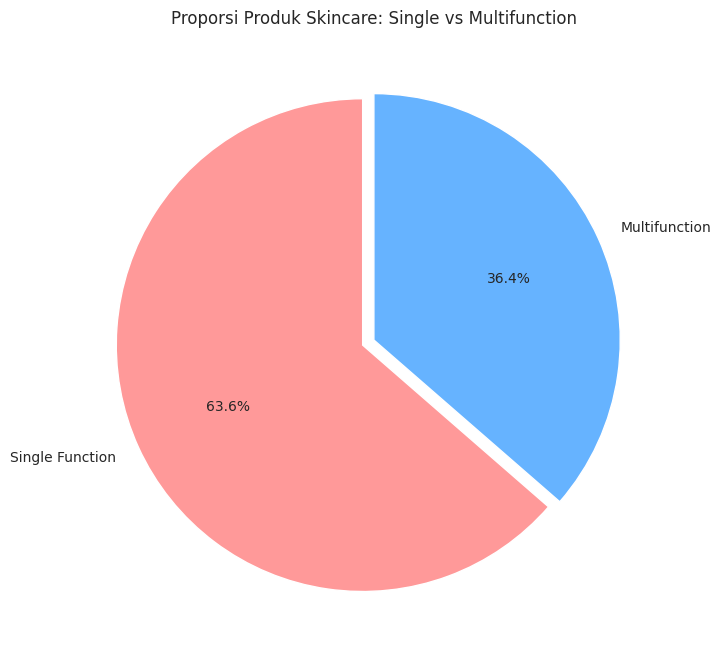

In [15]:
df_final['Is_Multifunction'] = df_final['Kategori_Cuaca'].str.contains('&')

multifungsi_count = df_final['Is_Multifunction'].sum()
total_produk = len(df_final)
persentase_multifungsi = (multifungsi_count / total_produk) * 100

print(f"Total Produk: {total_produk}")
print(f"Jumlah Produk Multifungsi: {multifungsi_count}")
print(f"Persentase Produk Multifungsi: {persentase_multifungsi:.2f}%")

plt.figure(figsize=(8, 8))
df_final['Is_Multifunction'].value_counts().plot.pie(
    autopct='%1.1f%%',
    labels=['Single Function', 'Multifunction'],
    colors=['#ff9999','#66b3ff'],
    startangle=90,
    explode=(0.05, 0)
)
plt.title('Proporsi Produk Skincare: Single vs Multifunction')
plt.ylabel('')
plt.show()

Analisis ini mengukur seberapa banyak produk dalam dataset yang mampu menangani lebih dari satu masalah kulit akibat cuaca secara bersamaan.
*   **Tingginya Produk Multifungsi (~36-40%):**
      Berdasarkan perhitungan, sebagian besar produk tidak hanya berdiri sendiri dengan satu fungsi. Kombinasi yang paling umum ditemukan adalah Hydrator & Sebum Controller. Hal ini mencerminkan kebutuhan pasar akan produk yang bisa melembapkan sekaligus mengontrol minyak, terutama untuk pengguna di iklim tropis.

*   **Efisiensi Penggunaan:**
      Produk multifungsi merupakan core value bagi sistem GlowMinder. Dengan banyaknya produk kategori ini, sistem dapat memberikan rekomendasi yang lebih cerdas. Misalnya, daripada menyarankan dua produk terpisah, sistem dapat menyarankan satu produk hybrid yang mencakup perlindungan cuaca sekaligus hidrasi.



**Kesimpulan Akhir EDA:**




Data menunjukkan bahwa industri skincare sedang bergerak menuju produk yang versatile (serbaguna). Hal ini divalidasi oleh rendahnya produk yang hanya memiliki label Weather Protector murni (hanya 1.2%), karena fungsi proteksi tersebut hampir selalu dibarengi dengan fungsi hidrasi atau kontrol sebum.

# **🏁 Final Conclusion & Strategic Recommendation**

## **1. Kesimpulan Utama (The Big Picture)**

Berdasarkan analisis data terhadap 1.000+ produk skincare, proyek GlowMinder menemukan bahwa pasar saat ini sangat didominasi oleh fungsi Hidrasi (52%). Namun, terdapat peluang besar pada produk Multifungsi (36.4%) yang mampu menangani perlindungan cuaca sekaligus kontrol sebum atau hidrasi. Produk Sunscreen terbukti menjadi kategori yang paling adaptif ("The Savior") untuk perubahan cuaca mendadak karena tingginya fungsionalitas hybrid-nya.

## **2. Rekomendasi Fitur Aplikasi (GlowMinder Roadmap)**

*   **Weather-Driven Smart Alarm:**
      Implementasikan sistem notifikasi real-time yang menyarankan penggunaan Sunscreen Hybrid saat UV Index naik drastis atau Rich Moisturizer saat kelembapan udara turun di bawah 40%.

*   **Skinimalist Routine: **
      Gunakan data produk multifungsi untuk menyederhanakan rutin pengguna. Jika sistem mendeteksi produk yang memiliki label Hydrator & Sebum Controller, sarankan produk tersebut sebagai solusi efisien 2-in-1.

*   **Inventory Prioritization:**
      Dalam pengembangan bisnis, fokuslah pada kemitraan dengan brand yang memiliki variasi Moisturizer dan Serum hidrasi tinggi, karena kedua kategori ini adalah yang paling dicari dan tersedia secara melimpah dalam dataset.

    



In [16]:
# Mengubah kolom 'Kategori_Cuaca' menjadi angka (One-Hot Encoding)
# Drop_first=False agar semua kategori cuaca memiliki kolomnya masing-masing
df_model_ready = pd.get_dummies(df_final, columns=['Kategori_Cuaca'], prefix='Cuaca')

# Mari kita lihat hasilnya
display(df_model_ready.head())

,Nama Produk,Kategori,Ingredients_Cleaned,Key_Ingredient,Is_Multifunction,Cuaca_Daily Maintenance,Cuaca_Hydrator,Cuaca_Hydrator & Sebum Controller,Cuaca_Sebum Controller,Cuaca_Weather Protector,Cuaca_Weather Protector & Hydrator,Cuaca_Weather Protector & Hydrator & Sebum Controller,Cuaca_Weather Protector & Sebum Controller
0,The Ordinary Natural Moisturising Factors + HA...,Moisturizer,"[capric triglyceride, cetyl alcohol, propanedi...",Other,False,False,True,False,False,False,False,False,False
1,CeraVe Facial Moisturising Lotion SPF 25 52ml,Moisturizer,"[homosalate, glycerin, octocrylene, ethylhexyl...",Ceramide,True,False,False,False,False,False,False,True,False
2,The Ordinary Hyaluronic Acid 2% + B5 Hydration...,Moisturizer,"[sodium hyaluronate, sodium hyaluronate, panth...",Other,False,False,True,False,False,False,False,False,False
3,AMELIORATE Transforming Body Lotion 200ml,Moisturizer,"[ammonium lactate, c12-15, glycerin, prunus am...",Other,False,False,True,False,False,False,False,False,False
4,CeraVe Moisturising Cream 454g,Moisturizer,"[glycerin, cetearyl alcohol, capric triglyceri...",Ceramide,False,False,True,False,False,False,False,False,False


In [17]:
# 1. Mengubah kolom 'Kategori' (Moisturizer, Serum, Sunscreen) menjadi angka (One-Hot Encoding)
df_model_ready = pd.get_dummies(df_model_ready, columns=['Kategori'], prefix='Tipe')

# 2. Mengubah kolom 'Is_Multifunction' dari True/False menjadi angka 1 dan 0
df_model_ready['Is_Multifunction'] = df_model_ready['Is_Multifunction'].astype(int)

# Tampilkan beberapa kolom pertama untuk memastikan semuanya sudah jadi angka
display(df_model_ready.head())

,Nama Produk,Ingredients_Cleaned,Key_Ingredient,Is_Multifunction,Cuaca_Daily Maintenance,Cuaca_Hydrator,Cuaca_Hydrator & Sebum Controller,Cuaca_Sebum Controller,Cuaca_Weather Protector,Cuaca_Weather Protector & Hydrator,Cuaca_Weather Protector & Hydrator & Sebum Controller,Cuaca_Weather Protector & Sebum Controller,Tipe_Moisturizer,Tipe_Serum,Tipe_Sunscreen
0,The Ordinary Natural Moisturising Factors + HA...,"[capric triglyceride, cetyl alcohol, propanedi...",Other,0,False,True,False,False,False,False,False,False,True,False,False
1,CeraVe Facial Moisturising Lotion SPF 25 52ml,"[homosalate, glycerin, octocrylene, ethylhexyl...",Ceramide,1,False,False,False,False,False,False,True,False,True,False,False
2,The Ordinary Hyaluronic Acid 2% + B5 Hydration...,"[sodium hyaluronate, sodium hyaluronate, panth...",Other,0,False,True,False,False,False,False,False,False,True,False,False
3,AMELIORATE Transforming Body Lotion 200ml,"[ammonium lactate, c12-15, glycerin, prunus am...",Other,0,False,True,False,False,False,False,False,False,True,False,False
4,CeraVe Moisturising Cream 454g,"[glycerin, cetearyl alcohol, capric triglyceri...",Ceramide,0,False,True,False,False,False,False,False,False,True,False,False


In [18]:
# Menyimpan dataset yang sudah melewati tahap Feature Engineering
df_model_ready.to_csv('skincare_model_ready.csv', index=False)

print("[SUCCESS] Data final untuk model dan dashboard berhasil disimpan!")
print("Silakan cek panel folder di sebelah kiri Colab untuk mengunduhnya.")

[SUCCESS] Data final untuk model dan dashboard berhasil disimpan!
Silakan cek panel folder di sebelah kiri Colab untuk mengunduhnya.


In [19]:
%%writefile app.py
import streamlit as st
import pandas as pd

# Konfigurasi Halaman
st.set_page_config(page_title="GlowMinder Dashboard", layout="wide")

# Judul Dashboard
st.title("✨ GlowMinder: Skincare Weather Recommender")
st.write("Selamat datang di prototipe dashboard GlowMinder! Aplikasi ini merekomendasikan skincare berdasarkan cuaca.")

# Load Data
@st.cache_data
def load_data():
    # Membaca data yang sudah kita siapkan sebelumnya
    return pd.read_csv('skincare_model_ready.csv')

df = load_data()

# Menampilkan Cuplikan Data
st.subheader("Cuplikan Data Final")
st.dataframe(df.head(10))

Writing app.py


In [25]:
# 1. Menginstal Streamlit
!pip install streamlit -q

# 2. Mendapatkan IP Address ('Password' untuk membuka aplikasinya)
import urllib
print("👇👇👇 COPY PASSWORD DI BAWAH INI 👇👇👇")
print(urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())
print("👆👆👆 ============================== 👆👆👆\n")

# 3. Menjalankan aplikasi Streamlit dan membukanya ke publik (sementara)
!streamlit run app.py & npx -y localtunnel --port 8501

👇👇👇 COPY PASSWORD DI BAWAH INI 👇👇👇
34.50.168.96
👆👆👆 ============================== 👆👆👆

⠙

⠹⠸⠼⠴⠦your url is: https://three-hands-taste.loca.lt
2026-06-03 02:27:37.004 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.50.168.96:8501

  Stopping...
^C


In [26]:
%%writefile requirements.txt
streamlit
pandas
matplotlib
seaborn

Overwriting requirements.txt


In [27]:
%%writefile app.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Konfigurasi Halaman (Membuat Tampilan Melebar)
st.set_page_config(page_title="GlowMinder Dashboard", layout="wide")

# 2. Judul Utama Dashboard
st.title("✨ GlowMinder: Skincare Weather Recommender")
st.write("Selamat datang di dashboard interaktif GlowMinder! Aplikasi ini menganalisis karakteristik produk skincare berdasarkan kebutuhan perlindungan cuaca.")

# 3. Membaca Data Yang Sudah Siap (Cached agar Cepat)
@st.cache_data
def load_data():
    return pd.read_csv('skincare_model_ready.csv')

df = load_data()

# 4. Menampilkan Metrik Ringkasan di Bagian Atas
st.subheader("📊 Ringkasan Dataset")
col1, col2, col3 = st.columns(3)
col1.metric("Total Produk Teranalisis", len(df))
col2.metric("Produk Multifungsi (Hybrid)", int(df['Is_Multifunction'].sum()))
col3.metric("Produk Fungsi Tunggal", len(df) - int(df['Is_Multifunction'].sum()))

st.markdown("---")

# 5. Bagian Visualisasi Grafik (Dibagi Menjadi 2 Kolom Kiri & Kanan)
st.subheader("📈 Insight Hasil Exploratory Data Analysis (EDA)")
graph_col1, graph_col2 = st.columns(2)

with graph_col1:
    st.write("### Proporsi Produk: Single vs Multifunction")
    fig1, ax1 = plt.subplots(figsize=(6, 6))

    counts = df['Is_Multifunction'].value_counts()
    # Mengembalikan angka 0 dan 1 menjadi teks label agar mudah dibaca di grafik
    labels = ['Single Function' if x == 0 else 'Multifunction' for x in counts.index]

    ax1.pie(counts, autopct='%1.1f%%', labels=labels, colors=['#ff9999', '#66b3ff'], startangle=90)
    ax1.axis('equal')
    st.pyplot(fig1)

with graph_col2:
    st.write("### Distribusi Jumlah Produk Per Kategori")
    fig2, ax2 = plt.subplots(figsize=(7, 6))

    # Menghitung total data dari kolom One-Hot Encoding yang sudah kamu buat
    tipe_counts = {
        'Moisturizer': df['Tipe_Moisturizer'].sum() if 'Tipe_Moisturizer' in df.columns else 0,
        'Serum': df['Tipe_Serum'].sum() if 'Tipe_Serum' in df.columns else 0,
        'Sunscreen': df['Tipe_Sunscreen'].sum() if 'Tipe_Sunscreen' in df.columns else 0
    }
    tipe_df = pd.DataFrame(list(tipe_counts.items()), columns=['Kategori', 'Jumlah'])

    sns.set_style("whitegrid")
    sns.barplot(data=tipe_df, x='Kategori', y='Jumlah', palette='Blues_d', ax=ax2)

    # Menambahkan angka di atas setiap batang grafik
    for p in ax2.patches:
        ax2.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', xytext=(0, 9), textcoords='offset points')

    ax2.set_ylim(0, max(tipe_df['Jumlah']) + 100)
    ax2.set_xlabel('Kategori Produk')
    ax2.set_ylabel('Jumlah Tipe Skincare')
    st.pyplot(fig2)

st.markdown("---")

# 6. Menampilkan Tabel Data Berisi Preview 10 Baris Pertama
st.subheader("📋 Cuplikan Data Hasil Feature Engineering")
st.dataframe(df.head(10))

Overwriting app.py


## A/B Testing: Proporsi Produk Multifungsi (Moisturizer vs Serum)
**Hipotesis:**
* **H0 (Null Hypothesis):** Tidak ada perbedaan signifikan proporsi produk multifungsi antara Moisturizer dan Serum.
* **H1 (Alternative Hypothesis):** Terdapat perbedaan signifikan proporsi produk multifungsi antara Moisturizer dan Serum.

In [28]:
import scipy.stats as stats
from scipy.stats import chi2_contingency
import numpy as np

# 1. Menyiapkan data kelompok A (Moisturizer) dan B (Serum)
moisturizer_data = df_final[df_final['Kategori'] == 'Moisturizer']['Is_Multifunction']
serum_data = df_final[df_final['Kategori'] == 'Serum']['Is_Multifunction']

# 2. Menghitung total dan jumlah yang multifungsi
moist_multi = moisturizer_data.sum()
moist_total = len(moisturizer_data)

serum_multi = serum_data.sum()
serum_total = len(serum_data)

print("--- RINGKASAN DATA ---")
print(f"Moisturizer Multifungsi : {moist_multi} dari {moist_total} produk ({(moist_multi/moist_total)*100:.2f}%)")
print(f"Serum Multifungsi       : {serum_multi} dari {serum_total} produk ({(serum_multi/serum_total)*100:.2f}%)\n")

# 3. Membuat tabel kontingensi untuk Chi-Square Test
contingency_table = np.array([
    [moist_multi, moist_total - moist_multi],
    [serum_multi, serum_total - serum_multi]
])

# 4. Melakukan Uji Statistik
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("--- HASIL A/B TESTING ---")
print(f"P-Value: {p_value:.5f}")

# 5. Menarik Kesimpulan
alpha = 0.05
if p_value < alpha:
    print("Kesimpulan: P-Value < 0.05 (Tolak H0).")
    print("🌟 Terdapat perbedaan proporsi yang SIGNIFIKAN secara statistik antara Moisturizer dan Serum dalam hal multifungsi.")
else:
    print("Kesimpulan: P-Value >= 0.05 (Gagal Tolak H0).")
    print("⚖️ TIDAK ada perbedaan proporsi yang signifikan antara keduanya. Perbedaan persentase kemungkinan terjadi secara kebetulan.")

--- RINGKASAN DATA ---
Moisturizer Multifungsi : 195 dari 652 produk (29.91%)
Serum Multifungsi       : 211 dari 570 produk (37.02%)

--- HASIL A/B TESTING ---
P-Value: 0.01013
Kesimpulan: P-Value < 0.05 (Tolak H0).
🌟 Terdapat perbedaan proporsi yang SIGNIFIKAN secara statistik antara Moisturizer dan Serum dalam hal multifungsi.
